<a href="https://colab.research.google.com/github/Mannesaketh/EML/blob/main/CANCER_CARE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI POWERED CANCER CARE DETECTION TO RECOVERY

Session-1

In [1]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import the dataset from the kaggle based on the suggestion
df = pd.read_csv('cancer_prediction_dataset.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB
None


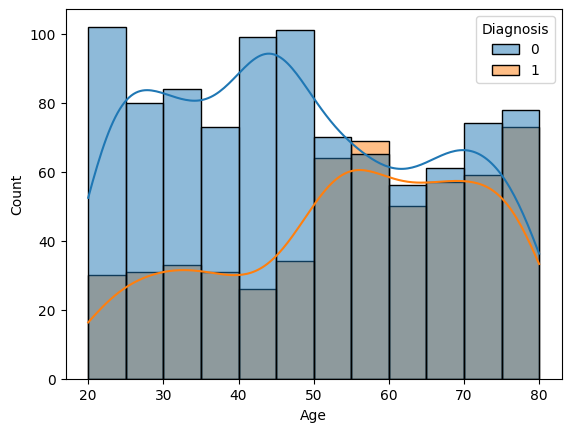

In [3]:
#represnt histograms age, diagnosis
sns.histplot(data=df, x='Age', hue='Diagnosis', kde=True)
plt.show()

In [4]:
print("Current Columns:", df.columns.tolist())

Current Columns: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory', 'Diagnosis']


In [5]:
df['BMI_Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [6]:
df = pd.get_dummies(df, columns=['Gender', 'BMI_Category'], drop_first=True)
df.to_csv('cleaned_cancer_data.csv', index=False)

In [7]:
df.to_csv('cleaned_cancer_data.csv', index=False)
print("Session 2 Complete: 'cleaned_cancer_data.csv' created successfully.")

Session 2 Complete: 'cleaned_cancer_data.csv' created successfully.


Session-3

In [8]:
#import
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [9]:
#Feature and Target Separation, Train-Test Split
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Train Models
log_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
dt_model = DecisionTreeClassifier(max_depth=5).fit(X_train, y_train)

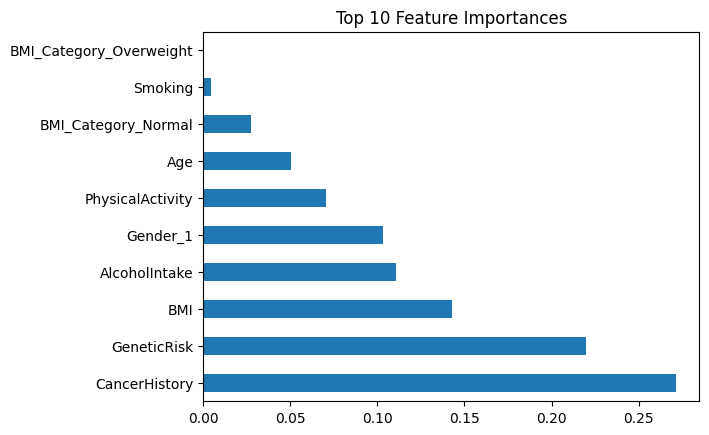

In [11]:
# Feature Importance
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

Session-4

In [12]:
#RandomForestClassifier, XGBoost

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [13]:
#load the new datset related to
df_global = pd.read_csv('global_cancer_patients.csv')
print(df_global['Cancer_Type'].value_counts())

Cancer_Type
Colon       6376
Prostate    6308
Leukemia    6266
Liver       6249
Skin        6231
Cervical    6222
Breast      6189
Lung        6159
Name: count, dtype: int64


In [14]:
X = df_global.drop('Cancer_Type', axis=1)
y = df_global['Cancer_Type']

# Identify categorical columns for one-hot encoding
categorical_cols = ['Gender', 'Country_Region', 'Cancer_Stage']

# Apply one-hot encoding to the categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<Figure size 1000x800 with 0 Axes>

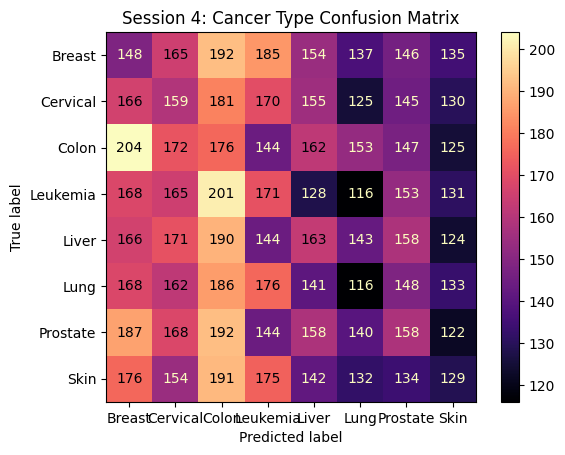

In [15]:
# Drop 'Patient_ID' column from X_train and X_test, as it's not a feature
# Checking if 'Patient_ID' exists before dropping to avoid errors if it's already gone.
if 'Patient_ID' in X_train.columns:
    X_train_processed = X_train.drop('Patient_ID', axis=1)
    X_test_processed = X_test.drop('Patient_ID', axis=1)
else:
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

# Initialize and fit the RandomForestClassifier again to ensure it's trained
rf_diag = RandomForestClassifier(n_estimators=100, random_state=42)
rf_diag.fit(X_train_processed, y_train)

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(rf_diag, X_test_processed, y_test, cmap='magma')
plt.title("Session 4: Cancer Type Confusion Matrix")
plt.show()

In [16]:
# Train Random Forest Classifier
rf_diag = RandomForestClassifier(n_estimators=100, random_state=42)
# Drop 'Patient_ID' column as it's a string and not a feature
X_train_processed = X_train.drop('Patient_ID', axis=1)
X_test_processed = X_test.drop('Patient_ID', axis=1)
rf_diag.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

<Figure size 1000x800 with 0 Axes>

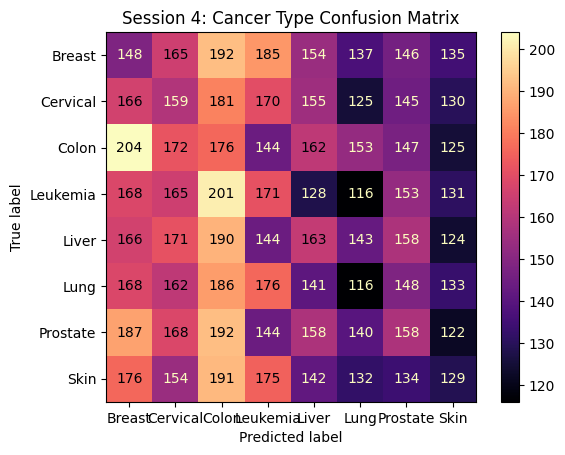

In [17]:
#Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(rf_diag, X_test_processed, y_test, cmap='magma')
plt.title("Session 4: Cancer Type Confusion Matrix")
plt.show()

In [18]:
# Print F1-scores (Macro and Weighted)
print(classification_report(y_test, rf_diag.predict(X_test_processed)))

              precision    recall  f1-score   support

      Breast       0.11      0.12      0.11      1262
    Cervical       0.12      0.13      0.12      1231
       Colon       0.12      0.14      0.13      1283
    Leukemia       0.13      0.14      0.13      1233
       Liver       0.14      0.13      0.13      1259
        Lung       0.11      0.09      0.10      1230
    Prostate       0.13      0.12      0.13      1269
        Skin       0.13      0.10      0.11      1233

    accuracy                           0.12     10000
   macro avg       0.12      0.12      0.12     10000
weighted avg       0.12      0.12      0.12     10000



Session-5

In [19]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [20]:
df_s5 = pd.read_csv('colorectal_cancer_prediction.csv')

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [22]:
xgb_clf = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)

# Drop 'Patient_ID' column from X_train and X_test
X_train_processed = X_train.drop('Patient_ID', axis=1)
X_test_processed = X_test.drop('Patient_ID', axis=1)

xgb_clf.fit(X_train_processed, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [23]:
y_pred_xgb = xgb_clf.predict(X_test_processed)
print("XGBoost predictions generated.")

XGBoost predictions generated.


<Figure size 1000x800 with 0 Axes>

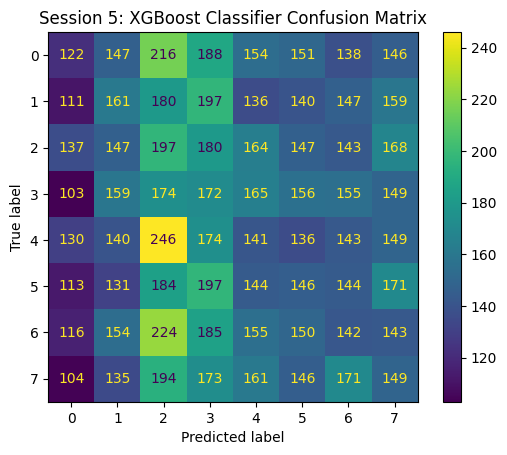

In [24]:
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(xgb_clf, X_test_processed, y_test_enc, cmap='viridis')
plt.title("Session 5: XGBoost Classifier Confusion Matrix")
plt.show()

In [25]:
# Target is 'Time_to_Recurrence' (Numeric)
X_surv = df_s5.drop(['Time_to_Recurrence', 'Patient_ID'], axis=1, errors='ignore')
X_surv = pd.get_dummies(X_surv, drop_first=True)
y_surv = df_s5['Time_to_Recurrence']

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_surv, y_surv, test_size=0.2, random_state=42)

In [26]:
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_reg.fit(Xs_train, ys_train)
print("XGBoost Regressor for survival prediction trained successfully.")

XGBoost Regressor for survival prediction trained successfully.


In [27]:
# checking the R-Square, evaluation
s_preds = xgb_reg.predict(Xs_test)
print(f"Survival MAE (Error in Months): {mean_absolute_error(ys_test, s_preds):.2f}")
print(f"Survival R² Score: {r2_score(ys_test, s_preds):.2f}")

Survival MAE (Error in Months): 14.91
Survival R² Score: -0.00


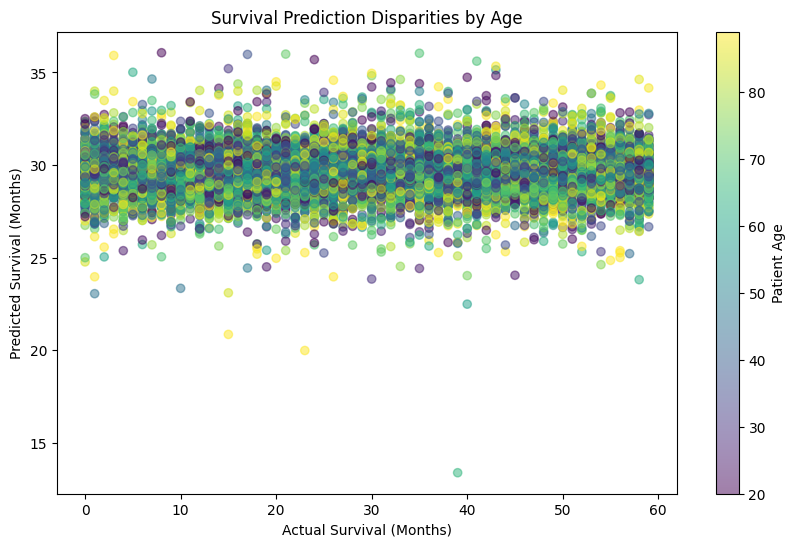

In [28]:
# Scatter plot of Actual vs Predicted Survival colored by Age
plt.figure(figsize=(10, 6))
plt.scatter(ys_test, s_preds, alpha=0.5, c=Xs_test['Age'], cmap='viridis')
plt.colorbar(label='Patient Age')
plt.xlabel("Actual Survival (Months)")
plt.ylabel("Predicted Survival (Months)")
plt.title("Survival Prediction Disparities by Age")
plt.show()

Session-6

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [30]:
# 1. Feature scaling and PCA (reduce to 2 components) [cite: 304, 305]
# Drop 'Patient_ID' column as it's not a feature and StandardScaler expects numerical input
X_processed = X.drop('Patient_ID', axis=1, errors='ignore')
X_scaled = StandardScaler().fit_transform(X_processed) # [cite: 304]
pca = PCA(n_components=2) # [cite: 305]
X_pca = pca.fit_transform(X_scaled)

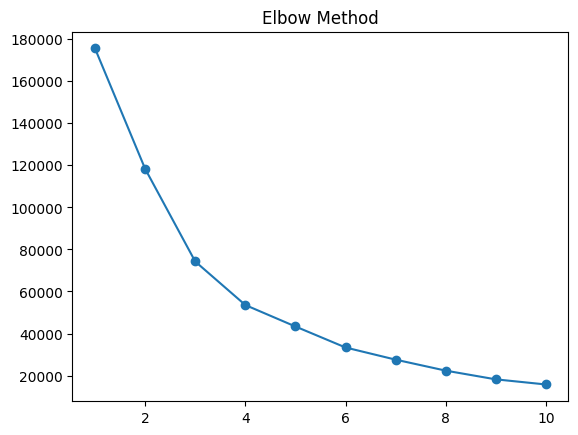

In [31]:
# 2. Use elbow method to determine optimal k
wcss = [KMeans(n_clusters=i, random_state=42).fit(X_pca).inertia_ for i in range(1, 11)]
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.show()

In [32]:
# Apply K-Means and visualize on 2D scatter plot
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

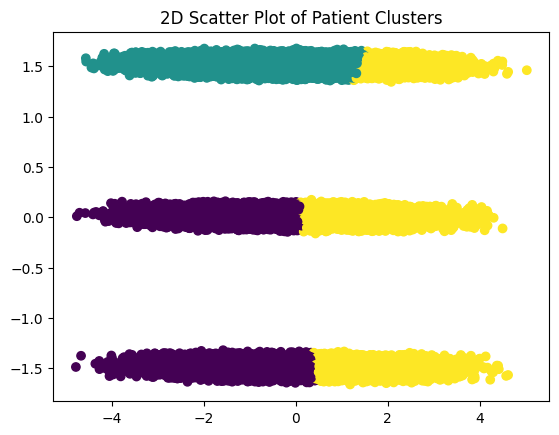

In [33]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis') # [cite: 310]
plt.title("2D Scatter Plot of Patient Clusters") # [cite: 310]
plt.show()

Session-7

In [34]:
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [35]:
df_rec = pd.read_csv('colorectal_cancer_prediction.csv')

In [36]:
# Create binary recurrence target from ys_train and ys_test
# Let's define recurrence as Time_to_Recurrence <= median_time_to_recurrence
median_time_to_recurrence = ys_train.median()
y_train_rec = (ys_train <= median_time_to_recurrence).astype(int)
y_test_rec = (ys_test <= median_time_to_recurrence).astype(int)

# Use Xs_train and Xs_test for features as they correspond to the df_rec dataset
fast_rec_model = LogisticRegression(max_iter=1000, random_state=42).fit(Xs_train, y_train_rec)

In [37]:
probs = fast_rec_model.predict_proba(Xs_test)[:, 1]
print("AUC-ROC:", roc_auc_score(y_test_rec, probs))

AUC-ROC: 0.5044269151188254


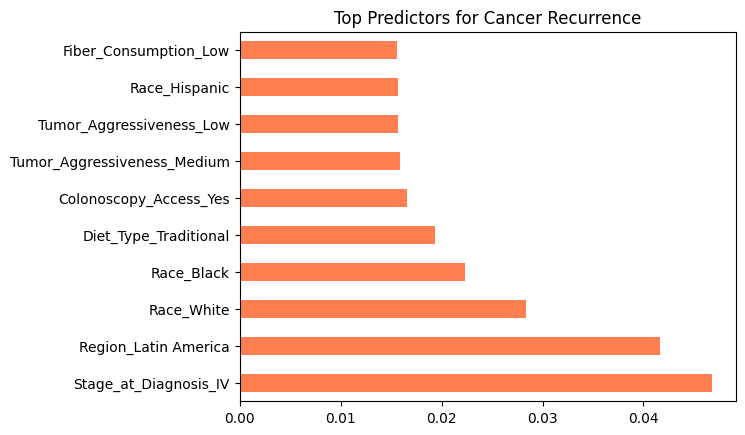

In [38]:
importances = pd.Series(fast_rec_model.coef_[0], index=Xs_train.columns)
importances.nlargest(10).plot(kind='barh', color='coral')
plt.title("Top Predictors for Cancer Recurrence")
plt.show()

In [39]:
G = nx.DiGraph()
states = ["Diagnosis", "Surgery", "Chemotherapy", "Radiation", "Remission", "Recurrence"]
G.add_nodes_from(states)

In [40]:
G.add_edge("Diagnosis", "Surgery", weight=0.8)
G.add_edge("Surgery", "Chemotherapy", weight=0.6)
G.add_edge("Chemotherapy", "Remission", weight=0.7)
G.add_edge("Remission", "Recurrence", weight=0.2)

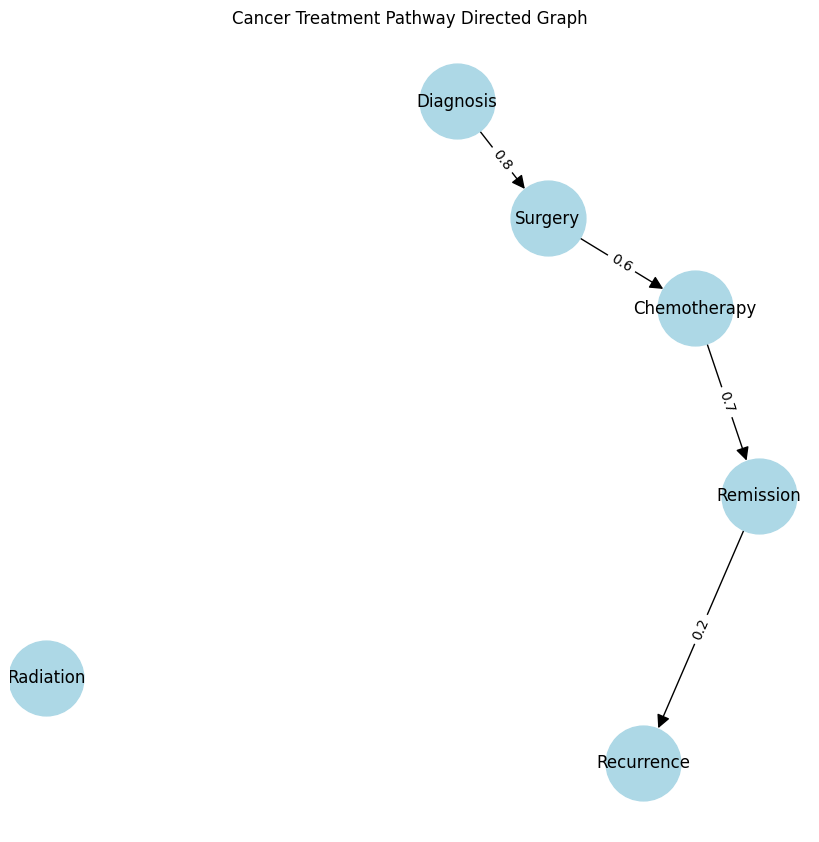

In [41]:
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2900, arrowsize=20)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Cancer Treatment Pathway Directed Graph")
plt.show()